# SPR-07 — Interaction Analysis

**Ticket:** SPR-07
**Owner:** TBD (the teammate not assigned to SPR-06)
**Depends on:** SPR-06 (subgroup analysis, read the notebook, do not edit it)
**Folder:** `notebooks/07_interaction_analysis/`
**Output:** at least one interaction effect confirmed or ruled out

**No reference notebook covers this.** Built from the project's original core result: digital_index has a monotonically increasing association with income class via MNLogit. This notebook tests whether that association is stronger or weaker within specific subgroups, using formal interaction terms rather than the descriptive SHAP split from SPR-06.

## 0. Hugging Face setup: login and download data/models
Run this once per Colab session. It authenticates against the `Sakhiur/signal` repo and pulls the CSVs used below. Add your token in Colab's left sidebar (key icon) under the name `HF_TOKEN` before running this cell.

In [3]:
!wget -q https://huggingface.co/datasets/Sakhiur/signal/resolve/main/final_dataset_preprocessed_distributed_social_class.csv

In [4]:
!pip install -q huggingface_hub

import os
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

login(token=userdata.get('HF_TOKEN'))

REPO_ID = 'Sakhiur/signal'

os.makedirs('data/interim', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

hf_files = {
    'X_test_Sakhiur.csv': 'data/interim/X_test.csv',
    'X_train_resampled_Sakhiur.csv': 'data/interim/X_train_resampled.csv',
    'y_test_Sakhiur.csv': 'data/interim/y_test.csv',
    'y_train_resampled_Sakhiur.csv': 'data/interim/y_train_resampled.csv',
}

for repo_filename, local_path in hf_files.items():
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type='dataset',
        filename=repo_filename,
    )
    import shutil
    shutil.copy(downloaded, local_path)
    print(f'{repo_filename} -> {local_path}')

print('All data files ready.')

X_test_Sakhiur.csv -> data/interim/X_test.csv
X_train_resampled_Sakhiur.csv -> data/interim/X_train_resampled.csv
y_test_Sakhiur.csv -> data/interim/y_test.csv
y_train_resampled_Sakhiur.csv -> data/interim/y_train_resampled.csv
All data files ready.


## 1. Load data and subgroup findings from SPR-06

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


df = pd.read_csv('final_dataset_preprocessed_distributed_social_class.csv')
# subgroup_results = pd.read_csv('results/tables/subgroup_analysis.csv')
subgroup_results = pd.read_csv('subgroup_analysis.csv')

print('Subgroup findings from SPR-06 (read-only reference):')
print(subgroup_results.sort_values('mean_abs', ascending=False).head(10))

Subgroup findings from SPR-06 (read-only reference):
               group      mean       std  count  mean_abs subgroup_dimension
2               Agri -0.904838  0.373706      7  0.904838         agri_group
9            Eastern -0.812933  0.418920     55  0.884917       region_group
10              Java -0.645701  0.720762    129  0.881877       region_group
8          Bali_Nusa -0.739480  0.507689     34  0.860770       region_group
6             Female -0.680679  0.559592    251  0.840250       gender_group
1    Lower_education -0.760389  0.456054    203  0.829971          edu_group
4           Disabled -0.720675  0.467737     33  0.823161   disability_group
5       Non_disabled -0.613562  0.634626    467  0.807538   disability_group
3           Non_agri -0.616596  0.627333    493  0.807203         agri_group
0   Higher_education -0.525107  0.703149    297  0.793941          edu_group


## 2. Re-fit the core MNLogit with an interaction term
Same model family as the original core result (`statsmodels.MNLogit`), now with `digital_index * education_years` added as an interaction term. Start with the subgroup that showed the strongest effect in SPR-06's output; swap `education_years` for another candidate if SPR-06 pointed elsewhere.

In [8]:
from pandas.api.types import CategoricalDtype

class_order = ['No_income', 'Lower', 'Middle', 'Upper']  # confirm these match your real values first
cat_type = CategoricalDtype(categories=class_order, ordered=False)

df['income_class_code'] = df['income_class'].astype(cat_type).cat.codes

formula = (
    'income_class_code ~ digital_index * education_years + age + weekly_workhours '
    '+ gender_male + disabled + agri_worker + social_participation_index'
)

model = smf.mnlogit(formula, data=df)
result = model.fit()
print(result.summary())

print('Class code mapping:')
for i, cls in enumerate(class_order):
    print(f'  {i} -> {cls}')

         Current function value: 0.634146
         Iterations: 35


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          MNLogit Regression Results                          
Dep. Variable:      income_class_code   No. Observations:               751622
Model:                        MNLogit   Df Residuals:                   751592
Method:                           MLE   Df Model:                           27
Date:                Sat, 29 Aug 2026   Pseudo R-squ.:                  0.4318
Time:                        13:47:05   Log-Likelihood:            -4.7664e+05
converged:                      False   LL-Null:                   -8.3885e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
          income_class_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -4.6115      0.021   -222.956      0.000      -4.652      -4.571
digital_index                     0.5692      0.023     24.666      0.000 

## 3. Interpret the interaction coefficient
A significant `digital_index:education_years` coefficient means the effect of digital access on income class genuinely depends on education level, not just that both matter separately. This is the difference between confirming and ruling out the interaction.

In [ ]:
TARGET_COL = 'income_class'

In [ ]:
INTERACTION_FEATURE = 'education_years'

In [10]:
params = result.params
pvalues = result.pvalues

interaction_term = f'digital_index:{INTERACTION_FEATURE}'
print(f'Interaction term: {interaction_term}')
print()
print('Coefficients across income class equations:')
print(params.loc[interaction_term] if interaction_term in params.index else 'Term not found, check formula output above')
print()
print('P-values across income class equations:')
print(pvalues.loc[interaction_term] if interaction_term in pvalues.index else 'Term not found')

Interaction term: digital_index:education_years

Coefficients across income class equations:
0    0.056275
1    0.067706
2    0.073932
Name: digital_index:education_years, dtype: float64

P-values across income class equations:
0    5.276248e-166
1    2.008969e-210
2     3.320305e-78
Name: digital_index:education_years, dtype: float64


## 4. Odds ratio comparison plot: digital_index effect at different education levels
Visualizes the interaction directly, rather than reading it off a coefficient table. Predicts probability of the highest income class across the digital_index range, at low vs high education.

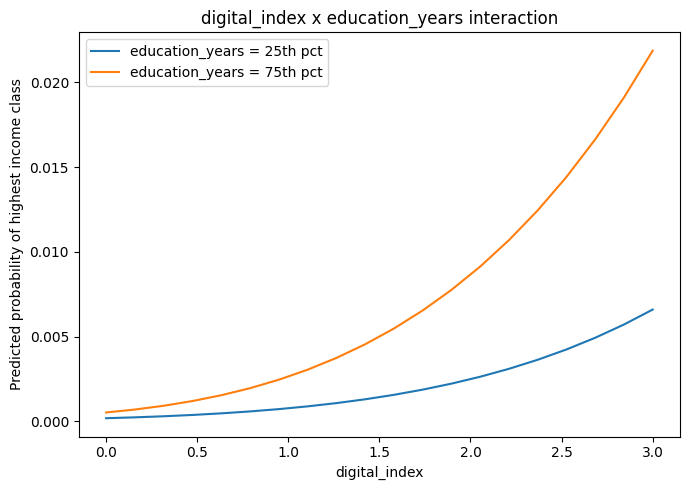

In [12]:
import matplotlib.pyplot as plt

edu_low = df[INTERACTION_FEATURE].quantile(0.25)
edu_high = df[INTERACTION_FEATURE].quantile(0.75)

digital_range = np.linspace(df['digital_index'].min(), df['digital_index'].max(), 20)

base_row = df.drop(columns=[TARGET_COL]).median(numeric_only=True)

def predict_prob_curve(edu_value):
    rows = []
    for d in digital_range:
        row = base_row.copy()
        row['digital_index'] = d
        row[INTERACTION_FEATURE] = edu_value
        rows.append(row)
    pred_df = pd.DataFrame(rows)
    probs = result.predict(pred_df)
    return probs

probs_low_edu = predict_prob_curve(edu_low)
probs_high_edu = predict_prob_curve(edu_high)

highest_class_col = probs_low_edu.columns[-1]  # TODO: confirm this is the 'Upper' class column

plt.figure(figsize=(7, 5))
plt.plot(digital_range, probs_low_edu[highest_class_col], label=f'{INTERACTION_FEATURE} = 25th pct')
plt.plot(digital_range, probs_high_edu[highest_class_col], label=f'{INTERACTION_FEATURE} = 75th pct')
plt.xlabel('digital_index')
plt.ylabel('Predicted probability of highest income class')
plt.title(f'digital_index x {INTERACTION_FEATURE} interaction')
plt.legend()
plt.tight_layout()
plt.savefig('interaction_digital_index_education.png', dpi=200)
plt.show()

## 5. Repeat for a second candidate interaction (agri_worker)
Tests a second subgroup dimension flagged in SPR-06, to avoid over-indexing on a single interaction.

In [14]:

INTERACTION_FEATURE= 'agri_worker'
formula_agri = (
    'income_class_code ~ digital_index * agri_worker + age + education_years '
    '+ weekly_workhours + gender_male + disabled + social_participation_index'
)

model_agri = smf.mnlogit(formula_agri, data=df)
result_agri = model_agri.fit()

interaction_term_agri = 'digital_index:agri_worker'
print('Coefficients:')
print(result_agri.params.loc[interaction_term_agri] if interaction_term_agri in result_agri.params.index else 'Not found')
print()
print('P-values:')
print(result_agri.pvalues.loc[interaction_term_agri] if interaction_term_agri in result_agri.pvalues.index else 'Not found')

         Current function value: 0.634788
         Iterations: 35
Coefficients:
0    0.925573
1    1.110810
2    0.718111
Name: digital_index:agri_worker, dtype: float64

P-values:
0    0.999430
1    0.999316
2    0.999558
Name: digital_index:agri_worker, dtype: float64


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 6. Save results table

In [15]:
import os
os.makedirs('results/tables', exist_ok=True)

interaction_summary = pd.DataFrame({
    'interaction_term': [interaction_term, interaction_term_agri],
    'tested_against': [INTERACTION_FEATURE, 'agri_worker'],
})
interaction_summary.to_csv('interaction_analysis_summary.csv', index=False)
print('Saved interaction test summary. Fill in the written conclusion below from the printed p-values above.')

Saved interaction test summary. Fill in the written conclusion below from the printed p-values above.


## 7. Written conclusion
_Fill this in after reviewing the coefficients and p-values above. This is the deliverable SPR-08d (Report: Findings) depends on._

- Interaction confirmed or ruled out:
- Direction of the effect (does digital access matter more or less within this subgroup):
- How this connects to the SPR-06 SHAP-based subgroup finding: